In [ ]:
# !pip install BorutaShap

# import scipy.stats as stats
# if not hasattr(stats, 'binom_test'):
#     stats.binom_test = lambda k, n, p=0.5, alternative='two-sided': stats.binomtest(k, n, p, alternative=alternative).pvalue

In [100]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import sparse
import sklearn
import altair as alt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer, make_column_selector, make_column_transformer
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from BorutaShap import BorutaShap

In [ ]:
# import os
# import gdown
# import pandas as pd

# folder_id = "1YH1UxyCxvj6BdptmOR3K_6XbZv8ipLMS"

# gdown.download_folder(id=folder_id, output="data", quiet=False)

# base_path = "data"

# ruta_base = os.path.join(base_path, "datos.csv")
# ruta_dic = os.path.join(base_path, "diccionario.csv")

# df = pd.read_csv(ruta_base, low_memory=False, encoding="latin1")
# # Clean column names from BOM characters and whitespace
# df.columns = df.columns.str.replace('ï»¿', '', regex=False).str.strip()

# # Cargar diccionario de forma robusta
# raw = pd.read_csv(ruta_dic, header=None, encoding="latin1")

# fila_inicio = None
# for i in range(len(raw)):
#     fila = raw.iloc[i].astype(str).str.lower()
#     if fila.str.contains("indicador").any() and fila.str.contains("mnem").any():
#         fila_inicio = i
#         break

# dic = pd.read_csv(ruta_dic, skiprows=fila_inicio, encoding="latin1")
# dic.columns = [str(c).strip() for c in dic.columns]

# col_mnem = [c for c in dic.columns if "mnem" in c.lower()][0]
# col_desc = [c for c in dic.columns if "desc" in c.lower()][0]
# col_rango = [c for c in dic.columns if "rang" in c.lower()][0]

# dic = dic[[col_mnem, col_desc, col_rango]]
# dic.columns = ["variable", "descripcion", "rangos"]
# dic = dic.dropna(subset=["variable"])

# print("Archivos cargados correctamente ✅")
# print("Filas:", len(df), "Columnas:", len(df.columns))

In [102]:
import sys
sys.path.append('../scripts')
from data_cleaner import DataCleaner
from data_cleaner import CleanerConfig

df = pd.read_csv('../data/inegi.csv',  low_memory=False)

# 1: Feature selection
df.head()
df.describe()

,ENTIDAD,MUN,LOC,ALTITUD,POBTOT,VIVTOT,TVIVHAB
count,2058.0,2058.000000,2058.000000,2022.000000,2.058000e+03,2058.000000,2058.000000
mean,1.0,4.732750,657.664723,1932.788823,2.084673e+03,678.517979,564.953839
std,0.0,3.293533,1243.027129,100.268193,4.248080e+04,13923.866900,11738.494349
min,1.0,0.000000,0.000000,1555.000000,1.000000e+00,1.000000,1.000000
25%,1.0,1.000000,109.250000,1890.000000,4.000000e+00,1.000000,1.000000
50%,1.0,5.000000,263.000000,1927.000000,9.000000e+00,4.000000,2.000000
75%,1.0,7.000000,492.000000,1994.000000,5.500000e+01,19.000000,13.000000
max,1.0,11.000000,9999.000000,2579.000000,1.425607e+06,463972.000000,386671.000000


In [103]:
# ---------------------------------
# Funciones de limpieza de datos censales
# ---------------------------------
VALORES_NO_DISPONIBLES = ["*", "N/D", "ND", "NA", "nan", ".", "", " "]

def limpiar_columna_numerica(serie):
    """Limpia una Serie individual y la convierte a numérico."""
    return (
        serie.astype(str)
             .str.strip()
             .replace(VALORES_NO_DISPONIBLES, np.nan)
             .str.replace(",", "", regex=False)
             .pipe(pd.to_numeric, errors="coerce")
    )

def limpiar_columnas_df(X):
    """
    Limpia múltiples columnas numéricas de valores censales no disponibles.
    Compatible con sklearn FunctionTransformer (recibe DataFrame o ndarray).
    """
    if not isinstance(X, pd.DataFrame):
        X = pd.DataFrame(X)
    else:
        X = X.copy()
    for col in X.columns:
        serie = X[col].astype(str).str.strip()
        serie = serie.replace(VALORES_NO_DISPONIBLES, np.nan)
        serie = serie.str.replace(",", "", regex=False)
        X[col] = pd.to_numeric(serie, errors="coerce")
    return X.values.astype(float)

In [104]:
# Parsear columna objetivo y filtrar filas sin valor
TARGET_COL = 'GRAPROES'

df[TARGET_COL] = limpiar_columna_numerica(df[TARGET_COL])
df = df.dropna(subset=[TARGET_COL])
df.drop(columns=[c for c in df.columns if c.startswith('P_')], inplace=True)
INTERFERENCE_COLS = ['GRAPROES_F', 'GRAPROES_M']
df.drop(columns=INTERFERENCE_COLS, inplace=True)

# ---------------------------------
# Grupos de columnas para el pipeline
# ---------------------------------
coord_cols = ['LONGITUD', 'LATITUD']           # coordenadas DMS → decimal
cat_cols   = ['NOM_ENT', 'NOM_MUN', 'NOM_LOC'] # texto identificador → descartar
num_cols   = [
    c for c in df.columns
    if c not in coord_cols + cat_cols + [TARGET_COL]
]

print(f"Numéricas : {len(num_cols)}")
print(f"Coordenadas: {len(coord_cols)}")
print(f"Categóricas (descartadas): {len(cat_cols)}")

Numéricas : 184
Coordenadas: 2
Categóricas (descartadas): 3


In [105]:
# Sampling 60% train 20% test 20% validation
train_df, temp_df = train_test_split(df, test_size=0.4, random_state=42)
test_df, val_df = train_test_split(temp_df, test_size=0.5, random_state=42)
train_df.head()

,ENTIDAD,NOM_ENT,MUN,NOM_MUN,LOC,NOM_LOC,LONGITUD,LATITUD,ALTITUD,POBTOT,...,VPH_CEL,VPH_INTER,VPH_STVP,VPH_SPMVPI,VPH_CVJ,VPH_SINRTV,VPH_SINLTC,VPH_SINCINT,VPH_SINTIC,TAMLOC
1232,1,Aguascalientes,6,Pabellón de Arteaga,100,San Pedro [Rancho],"102°15'34.559"" W","22°08'54.125"" N",1901.0,16,...,4,0,2,0,0,0,0,3,0,1
510,1,Aguascalientes,1,Aguascalientes,2402,San Miguel,"102°11'49.309"" W","21°53'47.597"" N",2020.0,104,...,20,5,2,2,1,0,2,15,0,1
1007,1,Aguascalientes,5,Jesús María,52,Mesa de las Carretas (Un Nuevo Amanecer),"102°26'19.748"" W","21°53'22.541"" N",2030.0,17,...,4,4,3,0,1,0,0,0,0,1
1254,1,Aguascalientes,6,Pabellón de Arteaga,183,El Mezquite [Colonia],"102°13'20.884"" W","22°04'47.345"" N",1969.0,141,...,24,4,13,0,0,1,6,25,0,1
913,1,Aguascalientes,3,Calvillo,9998,Localidades de una vivienda,NaN,NaN,NaN,173,...,39,9,9,1,1,4,8,37,3,*


In [106]:
# Describe
train_df.describe()

,ENTIDAD,MUN,LOC,ALTITUD,POBTOT,GRAPROES,VIVTOT,TVIVHAB
count,591.0,591.000000,591.000000,568.000000,591.000000,591.000000,591.000000,591.000000
mean,1.0,4.556684,728.470389,1928.614437,4276.998308,8.205195,1400.313029,1172.812183
std,0.0,3.281135,1685.357833,114.301240,53201.584186,1.852595,17588.706313,15028.804148
min,1.0,0.000000,0.000000,1555.000000,4.000000,0.000000,3.000000,3.000000
25%,1.0,1.000000,55.000000,1881.000000,19.000000,7.220000,7.000000,4.000000
50%,1.0,4.000000,212.000000,1931.000000,60.000000,8.090000,23.000000,14.000000
75%,1.0,7.000000,494.000000,1999.250000,380.000000,8.905000,127.000000,93.500000
max,1.0,11.000000,9999.000000,2512.000000,948990.000000,16.330000,313256.000000,266942.000000


In [ ]:
# Segmentación train test

X_train = train_df.drop(columns=[TARGET_COL]).copy()
y_train = train_df[TARGET_COL].copy()

X_test = test_df.drop(columns=[TARGET_COL]).copy()
y_test = test_df[TARGET_COL].copy()

In [108]:
# ---------------------------------
# Funciones auxiliares para el pipeline
# ---------------------------------
def parse_dms_matrix(X):
    """
    Parsea coordenadas DMS ('102°17\'45.768" W') a grados decimales.
    Compatible con sklearn FunctionTransformer.
    """
    def dms_to_decimal(s):
        try:
            s = str(s).strip()
            if not s or s in ('nan', 'NaN'):
                return np.nan
            direction = s[-1]
            num_part  = s[:-1].strip()
            parts     = re.split(r'[°\'"]', num_part)
            parts     = [p.strip() for p in parts if p.strip()]
            d   = float(parts[0])
            m   = float(parts[1]) if len(parts) > 1 else 0.0
            sec = float(parts[2]) if len(parts) > 2 else 0.0
            decimal = d + m / 60 + sec / 3600
            if direction in ('W', 'S'):
                decimal = -decimal
            return decimal
        except Exception:
            return np.nan

    if isinstance(X, pd.DataFrame):
        X = X.values
    X = np.array(X, dtype=object)
    result = np.empty((X.shape[0], X.shape[1]))
    for j in range(X.shape[1]):
        result[:, j] = [dms_to_decimal(v) for v in X[:, j]]
    return result


# ---------------------------------
# Pipelines especializados
# ---------------------------------

# Columnas numéricas: limpia valores censales → imputa → escala
num_pipeline = make_pipeline(
    FunctionTransformer(limpiar_columnas_df, validate=False),
    SimpleImputer(strategy="median"),
    StandardScaler(),
)

# Columnas de coordenadas: parsea DMS → imputa → escala
coord_pipeline = make_pipeline(
    FunctionTransformer(parse_dms_matrix, validate=False),
    SimpleImputer(strategy="median"),
    StandardScaler(),
)

In [109]:
# ---------------------------------
# Preprocesamiento completo
# ---------------------------------
preprocessing = ColumnTransformer(
    [
        ("numeric", num_pipeline, num_cols),
        ("coords",  coord_pipeline, coord_cols),
        # cat_cols (NOM_ENT, NOM_MUN, NOM_LOC) se descartan con remainder="drop"
    ],
    remainder="drop",
)

X_train_prepared = preprocessing.fit_transform(X_train)
if sparse.issparse(X_train_prepared):
    X_train_prepared = X_train_prepared.toarray()

# Los nombres de salida siguen el orden del ColumnTransformer: num_cols + coord_cols
feature_names_out = num_cols + coord_cols
X_train_prepared = pd.DataFrame(
    X_train_prepared,
    columns=feature_names_out,
    index=X_train.index,
)

print(f"Shape: {X_train_prepared.shape}")
X_train_prepared.head()

Shape: (591, 186)


,ENTIDAD,MUN,LOC,ALTITUD,POBTOT,POBFEM,POBMAS,REL_H_M,POB0_14,POB15_64,...,VPH_STVP,VPH_SPMVPI,VPH_CVJ,VPH_SINRTV,VPH_SINLTC,VPH_SINCINT,VPH_SINTIC,TAMLOC,LONGITUD,LATITUD
1232,0.0,0.440256,-0.373216,-0.247481,-0.080159,-0.080027,-0.080299,4.659445,-0.084244,-0.078880,...,-0.072157,-0.068197,-0.069521,-0.092901,-0.105056,-0.090813,-0.113987,-0.494428,0.213742,1.004955
510,0.0,-1.084898,0.993823,0.815424,-0.078504,-0.078196,-0.078829,-0.381642,-0.082457,-0.077235,...,-0.072157,-0.067765,-0.069208,-0.092901,-0.100062,-0.087874,-0.113987,-0.494428,0.542495,-0.495677
1007,0.0,0.135225,-0.401721,0.904744,-0.080141,-0.079917,-0.080376,0.840167,-0.084095,-0.078908,...,-0.072022,-0.068197,-0.069208,-0.092901,-0.105056,-0.091548,-0.113987,-0.494428,-0.727913,-0.537153
1254,0.0,0.440256,-0.323927,0.359894,-0.077808,-0.077390,-0.078248,-0.553235,-0.081117,-0.076844,...,-0.070671,-0.068197,-0.069521,-0.087538,-0.090076,-0.085425,-0.113987,-0.494428,0.408841,0.596445
913,0.0,-0.474836,5.504696,0.020479,-0.077206,-0.077207,-0.077204,0.128519,-0.081191,-0.076482,...,-0.071212,-0.067981,-0.069208,-0.071449,-0.085082,-0.082485,-0.040657,-0.494428,0.096645,-0.212160


In [110]:
# ---------------------------------
# Selección de características con BorutaShap
# ---------------------------------
feature_selector = BorutaShap(
    model=RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1,
        min_samples_leaf=2,
    ),
    importance_measure="shap",
    classification=False,
)

feature_selector.fit(
    X=X_train_prepared,
    y=y_train,
    n_trials=30,
    sample=False,
    train_or_test="test",
    normalize=True,
    verbose=True,
    random_state=42,
)

  0%|          | 0/30 [00:00<?, ?it/s]

21 attributes confirmed important: ['VPH_PC', 'VPH_SPMVPI', 'P15PRI_INF', 'P18YM_PB_F', 'PAFIL_IPRIV', 'P15YM_SE', 'P18YM_PB', 'PDER_ISTE', 'P18A24A_M', 'P15PRI_INM', 'P18A24A', 'VPH_SINCINT', 'PROM_HNV', 'PRO_OCUP_C', 'VPH_INTER', 'P15PRI_IN', 'P15YM_AN_F', 'P15YM_SE_F', 'P15YM_AN', 'P18YM_PB_M', 'P15PRI_CO']
159 attributes confirmed unimportant: ['P3YM_HLI', 'PCLIM_PMEN', 'PRESOE15_F', 'VPH_PISODT', 'PDER_IMSS', 'P3YM_HLI_M', 'TVIVPARHAB', 'PCDISC_MEN', 'VPH_SNBIEN', 'PRES2015_F', 'VPH_BICI', 'PCDISC_MOT', 'PNACOE_F', 'PAFIL_PDOM', 'P12YM_SEPA', 'VPH_1DOR', 'PNACOE_M', 'PE_INAC_F', 'PCLIM_MOT2', 'VPH_AGUADV', 'PCLIM_VIS', 'ENTIDAD', 'POB_AFRO_M', 'POCUPADA_F', 'P15A17A', 'PHOGJEF_F', 'VPH_AEASP', 'VIVPAR_UT', 'P8A14AN_F', 'PCDISC_LENG', 'P8A14AN', 'P3HLINHE', 'P15SEC_COF', 'P15SEC_COM', 'PCDISC_VIS', 'P15YM_AN_M', 'PDER_SEGP', 'VPH_SINTIC', 'VPH_1CUART', 'POBTOT', 'P12YM_SOLT', 'VPH_RADIO', 'PDESOCUP_F', 'VPH_NDEAED', 'LOC', 'VPH_AUTOM', 'VPH_TV', 'P5_HLI_HE', 'VPH_3YMASC', 'VPH_DREN

Seleccionadas : 21
Rechazadas    : 165


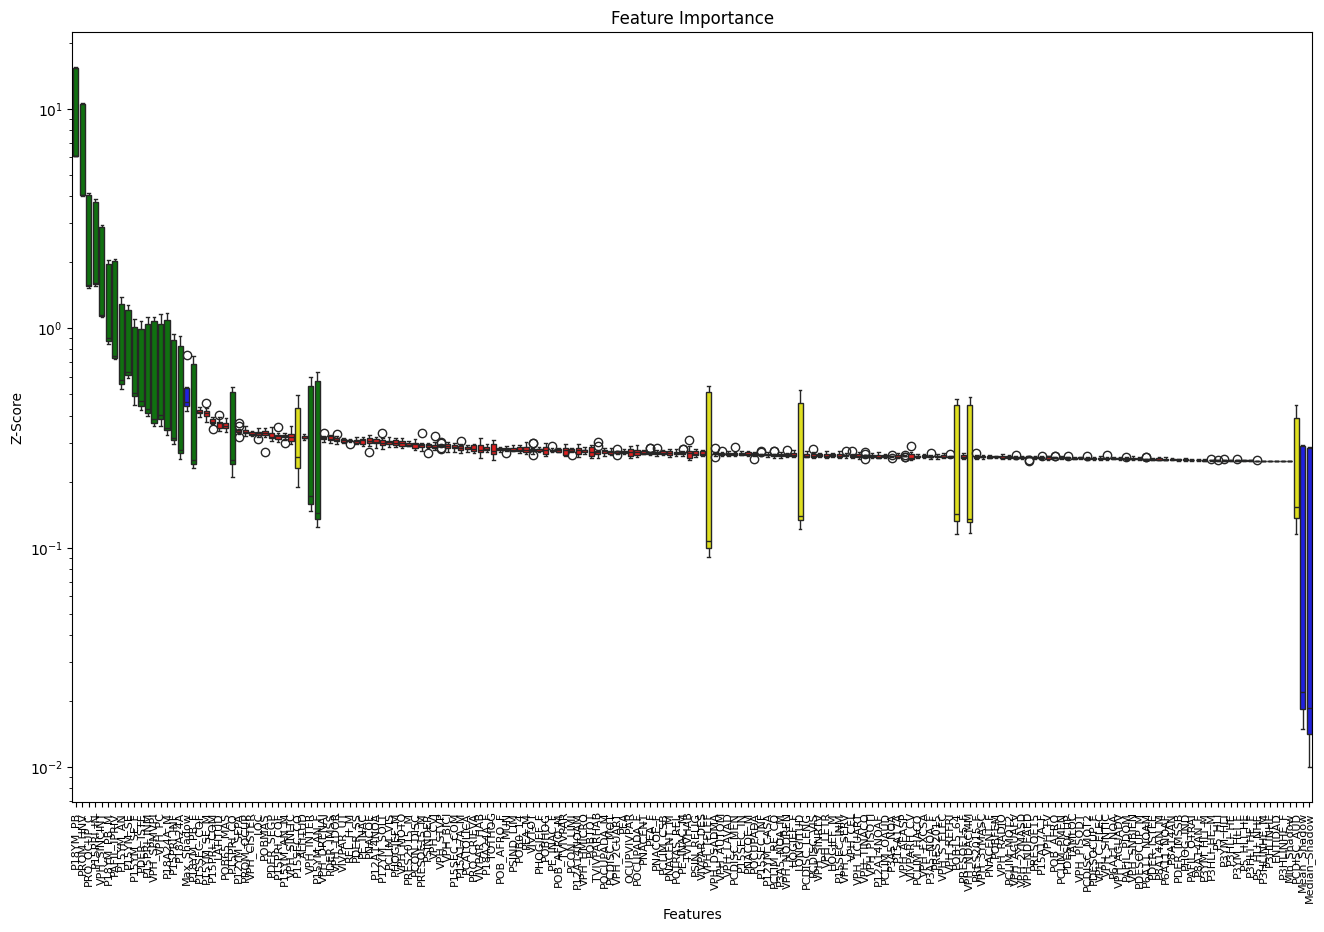

<Figure size 640x480 with 0 Axes>

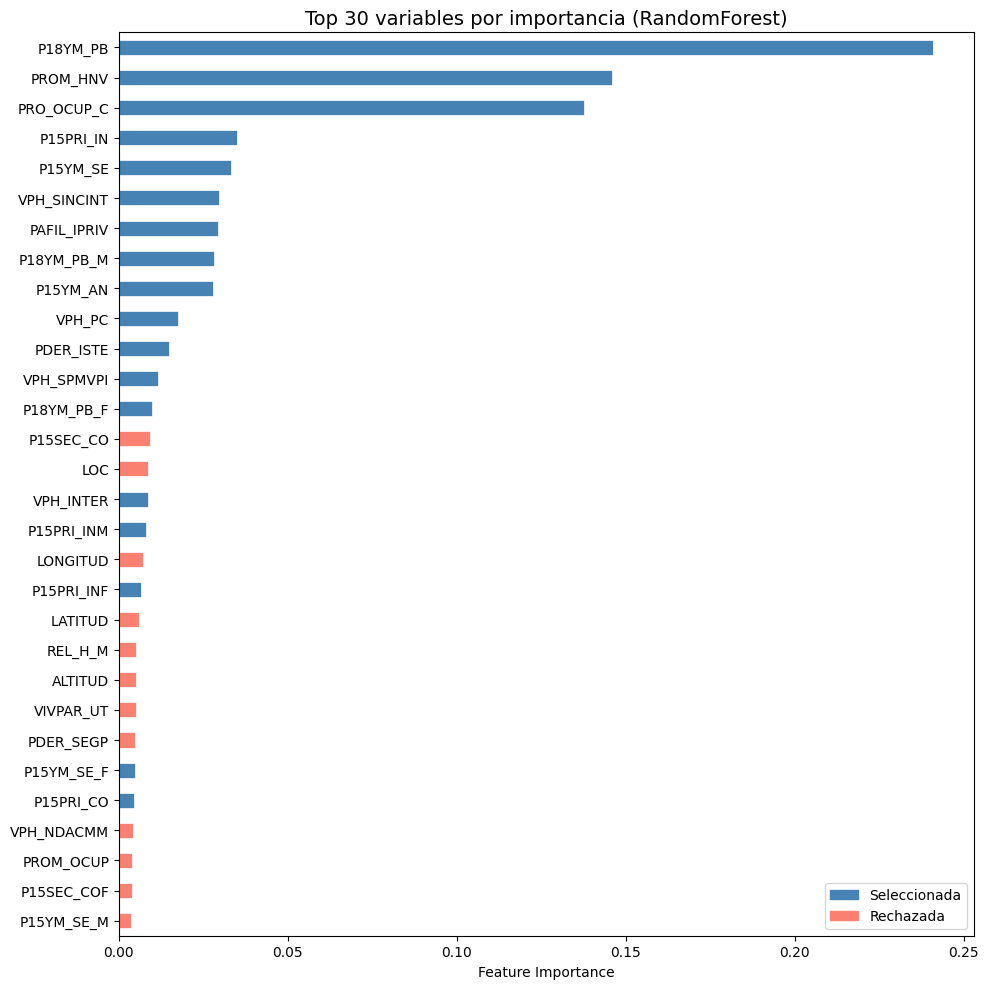

In [111]:
# ---------------------------------
# Resultados de BorutaShap
# ---------------------------------
selected_features = feature_selector.Subset().columns.tolist()
rejected_features = [c for c in X_train_prepared.columns if c not in selected_features]

print(f"Seleccionadas : {len(selected_features)}")
print(f"Rechazadas    : {len(rejected_features)}")

# --- Gráfica nativa de BorutaShap (SHAP values por trial) ---
feature_selector.plot(which_features='all', figsize=(16, 10), X_size=8)
plt.tight_layout()
plt.show()

# --- Top 30 variables por importancia (RF independiente) ---
rf_importance = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_importance.fit(X_train_prepared, y_train)

importances = (
    pd.Series(rf_importance.feature_importances_, index=X_train_prepared.columns)
    .sort_values(ascending=False)
)

top_n = 30
top = importances.head(top_n).iloc[::-1]

colors = ['steelblue' if f in selected_features else 'salmon' for f in top.index]

fig, ax = plt.subplots(figsize=(10, 10))
top.plot(kind='barh', ax=ax, color=colors, edgecolor='white', linewidth=0.5)
ax.set_title(f'Top {top_n} variables por importancia (RandomForest)', fontsize=14)
ax.set_xlabel('Feature Importance')

from matplotlib.patches import Patch
ax.legend(
    handles=[Patch(color='steelblue', label='Seleccionada'), Patch(color='salmon', label='Rechazada')],
    loc='lower right',
)
plt.tight_layout()
plt.show()